# 1. IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD DATASET

In [3]:
df = pd.read_csv('../data/raw/Data_kasuskriminal_sungai_pinyuh.csv')

print("Data berhasil dimuat!")

Data berhasil dimuat!


# 3. PREVIEW DATA

In [4]:
df.head()

,NO,NO & TGL LAPORAN POLISI,PERKARA,TKP,PELAPOR,TERLAPOR,MO,BARANG BUKTI,PROSES,KET
0,1,LP/B/01/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Penganiayaan,"Dusun Melati, Sungai Purun Kecil, Kec. Sungai ...",EMIL PERMATA,LIE,Pelaku merasa tersinggung dengan tatapan korba...,Hasil Visum et Repertum,Sidik,Tipiring Sidang PN
1,2,LP/B/02/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Pencurian,"Gg. Usaha RT 20/RW 09, Sungai Batang, Kec. Sun...",DINI,PASARIBU,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",Perhiasan emas,Sidik,P. 21 Tahap II
2,3,LP/B/03/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Pencurian,"Jl. Raya Nusapati RT 09/RW 05, Sungai Purun Ke...",ALFIN LIANG,FIKA,"Pelaku berpura-pura menjadi tamu/pembeli, saat...",1 buah HP,Sidik,Tahap I
3,4,LP/B/04/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Narkoba,"Dusun Sejahtera, Sungai Batang, Kec. Sungai Pi...",LESTARI IRAWAN,MANSUR FAJAR,Petugas mencurigai gerak-gerik pelaku di pingg...,Timbangan digital,Dalam Lidik,Lidik
4,5,LP/B/05/I/2021/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Narkoba,"Gg. Famili, Desa/Kel. Peniraman, Kec. Sungai P...",EKO YASIN NG,DADANG KARIM,Petugas mencurigai gerak-gerik pelaku di pingg...,Paket klip sabu,Sidik,P. 21 Tahap II


# 4. CEK STRUKTUR DATA

In [5]:
print("Shape:", df.shape)
print("\nKolom:")
print(df.columns)

print("\nInfo data:")
df.info()

Shape: (1050, 10)

Kolom:
Index(['NO', 'NO & TGL LAPORAN POLISI', 'PERKARA', 'TKP', 'PELAPOR',
       'TERLAPOR', 'MO', 'BARANG BUKTI', 'PROSES', 'KET'],
      dtype='object')

Info data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NO                       1050 non-null   int64 
 1   NO & TGL LAPORAN POLISI  1050 non-null   object
 2   PERKARA                  1050 non-null   object
 3   TKP                      1050 non-null   object
 4   PELAPOR                  1040 non-null   object
 5   TERLAPOR                 1050 non-null   object
 6   MO                       1047 non-null   object
 7   BARANG BUKTI             777 non-null    object
 8   PROSES                   1050 non-null   object
 9   KET                      1050 non-null   object
dtypes: int64(1), object(9)
memory usage: 82.2+ KB


# 5. CEK MISSING VALUE

In [6]:
print("Jumlah Missing Value:")
print(df.isnull().sum())

print("\nPersentase Missing Value:")
print((df.isnull().sum()/len(df))*100)

Jumlah Missing Value:
NO                           0
NO & TGL LAPORAN POLISI      0
PERKARA                      0
TKP                          0
PELAPOR                     10
TERLAPOR                     0
MO                           3
BARANG BUKTI               273
PROSES                       0
KET                          0
dtype: int64

Persentase Missing Value:
NO                          0.000000
NO & TGL LAPORAN POLISI     0.000000
PERKARA                     0.000000
TKP                         0.000000
PELAPOR                     0.952381
TERLAPOR                    0.000000
MO                          0.285714
BARANG BUKTI               26.000000
PROSES                      0.000000
KET                         0.000000
dtype: float64


# 6. DISTRIBUSI KELAS (PENTING)

### 6.1 PERKARA

PERKARA
Pencurian       276
Penganiayaan    205
Penipuan        148
Perusakan       124
Narkoba          86
Penggelapan      84
Pengeroyokan     68
KDRT             52
Pencurian         4
Perusakan         1
Penipuan          1
Tipiring          1
Name: count, dtype: int64


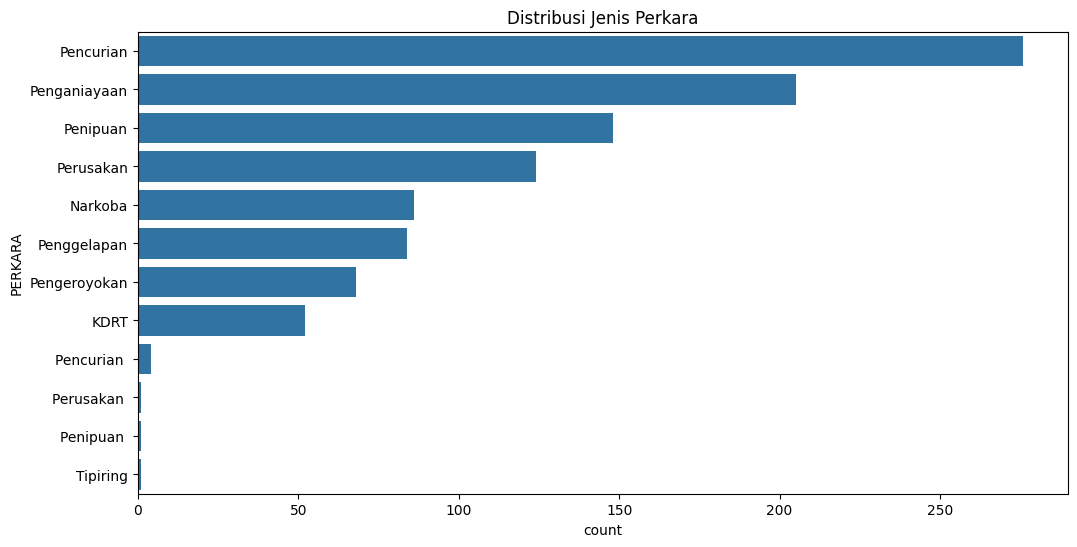

In [7]:
perkara_count = df['PERKARA'].value_counts()

print(perkara_count)

plt.figure(figsize=(12,6))
sns.countplot(
    y='PERKARA',
    data=df,
    order=perkara_count.index
)
plt.title("Distribusi Jenis Perkara")
plt.show()

### 6.2 Analisis Variabel MO

Panjang Teks MO

In [8]:
df['PANJANG_MO'] = df['MO'].astype(str).apply(len)

print(df['PANJANG_MO'].describe())

count    1050.00000
mean      128.42381
std        57.38006
min         3.00000
25%        96.25000
50%       118.00000
75%       142.00000
max       660.00000
Name: PANJANG_MO, dtype: float64


Visualisasi

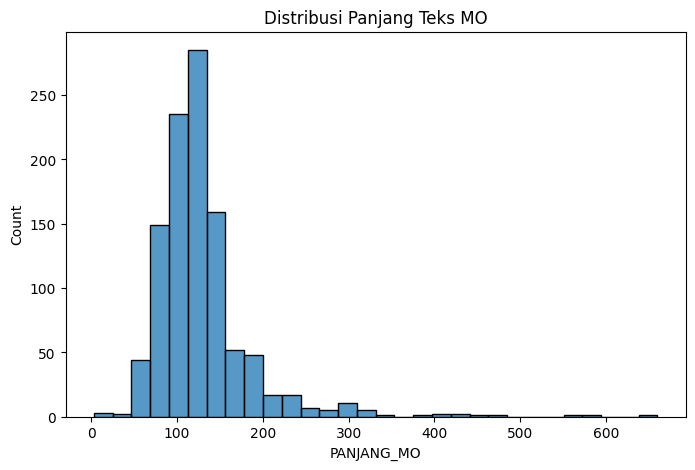

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['PANJANG_MO'], bins=30)
plt.title("Distribusi Panjang Teks MO")
plt.show()

### 6.3 Analisis Variabel BARANG BUKTI

Missing Value

In [10]:
df['BARANG BUKTI'].isnull().sum()

np.int64(273)

Jumlah Variasi

In [11]:
df['BARANG BUKTI'].nunique()

182

Barang Bukti Terbanyak

In [12]:
df['BARANG BUKTI'].value_counts().head(20)

BARANG BUKTI
Hasil Visum et Repertum                       64
Bukti transfer / Kwitansi                     42
Pecahan kaca/barang rusak                     36
Hasil Visum et Repertum.                      25
Uang tunai                                    20
Hasil Visum et Repertum, 1 potong kayu.       17
Barang bukti terkait.                         17
Perhiasan emas                                16
1 unit sepeda motor Yamaha NMAX               16
Bukti transfer, Kwitansi, Screenshot chat.    15
1 unit sepeda motor Honda Vario               14
Screenshot percakapan                         13
Kwitansi                                      13
1 unit HP Samsung Galaxy                      13
perhiasan emas seberat 10 gram                12
Pecahan piring (jika ada)                     12
Bukti transfer                                12
uang tunai Rp 5.000.000                       12
Pakaian korban                                11
Audit keuangan                                11
Name: c

Visualisasi

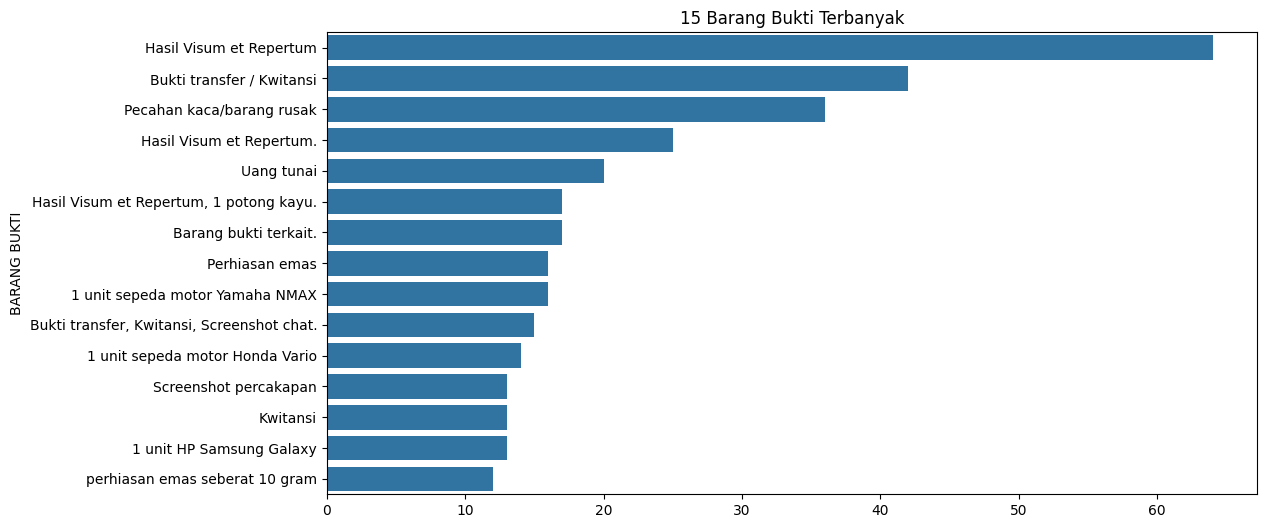

In [13]:
top_bb = df['BARANG BUKTI'].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_bb.values,
    y=top_bb.index
)

plt.title("15 Barang Bukti Terbanyak")
plt.show()

# 7. Hubungan PERKARA dengan BARANG BUKTI

In [14]:
pd.crosstab(
    df['PERKARA'],
    df['BARANG BUKTI']
)

BARANG BUKTI,"1 (satu) unit handphone (HP) merk Samsung J7 No. IMEI 352806090280136 dan 1 (satu) unit motor merk Honda Vario KB 2095 BY warna hitam tahun 2018, Noka : MH1JFU122JK205023, Nosin : JFU1E224796.",Rekaman CCTV,sound system,1 (satu) buah toples yang berisikan uang Rp. 55. 000(Lima Puluh Lima Ribu Rupiah),1 (satu) buah Aki kering merk XTRA AMF 55D 26R 12V 60AH warna hitam 1 (satu) buah Aki kering merk TAG 48D 26R 12V 50 AH warna hitam,1 (satu) buah Cburator,1 (satu) buah HP merk Xiaomi.,1 (satu) buah Mesin air.,1 (satu) buah Tabung gas 3kg.,1 (satu) buah Uang tunai.,...,"sepeda motor merk Honda Vario, BPKB, STNK.","sepeda motor merk Yamaha Mio, BPKB, STNK.","sepeda motor merk Yamaha NMAX, BPKB, STNK.","tabung gas, Kotak/Dus.",timbangan digital,uang tunai Rp 5.000.000,"uang tunai sebesar Rp 1.000.000, Kotak/Dus.","uang tunai sebesar Rp 2.500.000, Kotak/Dus.","uang tunai sebesar Rp 5.000.000, Kotak/Dus.","uang tunai sebesar Rp 500.000, Kotak/Dus."
PERKARA,,,,,,,,,,,,,,,,,,,,,
KDRT,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Narkoba,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
Pencurian,1,0,0,1,1,1,1,1,1,1,...,1,1,1,1,0,10,2,1,1,1
Pencurian,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Penganiayaan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pengeroyokan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Penggelapan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0
Penipuan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Penipuan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 8. Duplikasi data terhadapat variabel

Menghitung Jumlah Duplikasi

In [15]:
duplicate_count = df[['MO', 'BARANG BUKTI', 'PERKARA']].duplicated().sum()

print(f"Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 295


Melihat Data yang Duplikat

In [16]:
duplicate_rows = df[
    df[['MO', 'BARANG BUKTI', 'PERKARA']]
    .duplicated(keep=False)
]

duplicate_rows = duplicate_rows.sort_values(
    by=['PERKARA', 'MO', 'BARANG BUKTI']
)

duplicate_rows

,NO,NO & TGL LAPORAN POLISI,PERKARA,TKP,PELAPOR,TERLAPOR,MO,BARANG BUKTI,PROSES,KET,PANJANG_MO
177,178,LP/B/178/X/2021/Kalbar/Res Mpw/Sek Sui Pinyuh ...,KDRT,"Dusun Sejahtera, Sungai Bakau Besar Laut, Kec....",HERU MELATI CIPTO,CINTA LESMANA,"Korban meminta uang belanja kepada pelaku, nam...",NaN,Sidik,P. 21 Tahap II,107
829,830,LP/B/185/XI/2024/Kalbar/Res/Mpw/Sek/Sui Pinyuh...,KDRT,"Dusun Sejahtera, Sungai Bakau Besar Laut, Kec....",SANDI WIJAYA,HERA ALAMSYAH,"Korban meminta uang belanja kepada pelaku, nam...",NaN,Sidik,Tahap I,107
839,840,LP/B/195/XI/2024/Kalbar/Res/Mpw/Sek/Sui Pinyuh...,KDRT,"Dusun Mawar, Nusapati, Kec. Sungai Pinyuh",IKA VIRA,DEDEN KURNIA,"Korban meminta uang belanja kepada pelaku, nam...",NaN,Dalam Lidik,Lidik,131
996,997,LP/B/135/X/2025/Kalbar/Res/Mpw/Sek/Sui Pinyuh ...,KDRT,"Gg. Nelayan RT 15/RW 01, Sungai Bakau Besar La...",WAWAN RAHAYU,AIS SUTRISNO,"Korban meminta uang belanja kepada pelaku, nam...",NaN,SIDIK,TAHAP I,131
333,334,LP/B/106/VII/2022/Kalbar/Res Mpw/Sek Sui Pinyu...,KDRT,"Jl. Raya, Desa/Kel. Sungai Batang, Kec. Sungai...",RANI,RENDIAN,Pelaku (suami) memukul korban (istri) di bagia...,NaN,Sidik,Tipiring Sidang PN,106
...,...,...,...,...,...,...,...,...,...,...,...
845,846,LP/B/201/XII/2024/Kalbar/Res/Mpw/Sek/Sui Pinyu...,Perusakan,"Gg. Mawar, Desa/Kel. Galang, Kec. Sungai Pinyu...",YOGA ATMADJA,SITI HAMZAH TAMBUNAN,Pelaku merusak pagar tanaman milik korban deng...,Pecahan kaca/barang rusak,Sidik,Tahap I,112
652,653,LP/B/08/I/2024/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Perusakan,"Dusun Tengah, Desa/Kel. Sungai Rasau, Kec. Sun...",LESTARI SUSANTO,DALAM LIDIK,Pelapor terkejut melihat kaca mobil miliknya r...,"Pecahan mobil, Foto kerusakan.",Dalam Lidik,Lidik,122
708,709,LP/B/64/V/2024/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Perusakan,"Dusun Tengah, Desa/Kel. Sungai Rasau, Kec. Sun...",LESTARI SUSANTO,DALAM LIDIK,Pelapor terkejut melihat kaca mobil miliknya r...,"Pecahan mobil, Foto kerusakan.",Dalam Lidik,Lidik,122
648,649,LP/B/04/I/2024/Kalbar/Res Mpw/Sek Sui Pinyuh t...,Perusakan,"Jl. Parit Akop, Desa/Kel. Sungai Bakau Besar D...",DIAN,FAJAR SUSANTO,Pelapor terkejut melihat pagar rumah miliknya ...,"Pecahan rumah, Foto kerusakan.",Dalam Lidik,Lidik,119


Menampilkan Kelompok Duplikat

In [17]:
duplicate_groups = (
    df.groupby(['MO', 'BARANG BUKTI', 'PERKARA'])
      .size()
      .reset_index(name='FREKUENSI')
      .query('FREKUENSI > 1')
      .sort_values('FREKUENSI', ascending=False)
)

duplicate_groups

,MO,BARANG BUKTI,PERKARA,FREKUENSI
353,Pelaku menjanjikan pekerjaan kepada korban den...,Bukti transfer / Kwitansi,Penipuan,13
502,Tertangkap tangan memiliki dan menyimpan narko...,1 klip plastik transparan berisi serbuk krista...,Narkoba,10
254,Pelaku memukul wajah korban dengan tangan koso...,"Hasil Visum et Repertum, 1 potong kayu.",Penganiayaan,9
383,Pelaku merusak kaca jendela rumah korban denga...,Pecahan kaca/barang rusak,Perusakan,9
225,Pelaku memecahkan kaca mobil korban menggunaka...,Pecahan kaca/barang rusak,Perusakan,9
...,...,...,...,...
492,Terjadi tindak pidana penganiayaan yang dilaku...,Hasil Visum et Repertum.,Penganiayaan,2
497,Terlapor menyewa mobil pelapor a.n. Edi Saputr...,1 (satu) unit mobil merk Daihatsu Grand Max Ta...,Penggelapan,2
504,"Tertangkap tangan memiliki, menyimpan, dan men...",2 butir pil ekstasi,Narkoba,2
505,"Tertangkap tangan memiliki, menyimpan, dan men...",alat hisap sabu (bong),Narkoba,2


In [18]:
print(f"Jumlah kelompok duplikat: {len(duplicate_groups)}")

print(f"Total baris yang terlibat duplikasi: {duplicate_groups['FREKUENSI'].sum()}")

Jumlah kelompok duplikat: 117
Total baris yang terlibat duplikasi: 362


Visualisasi

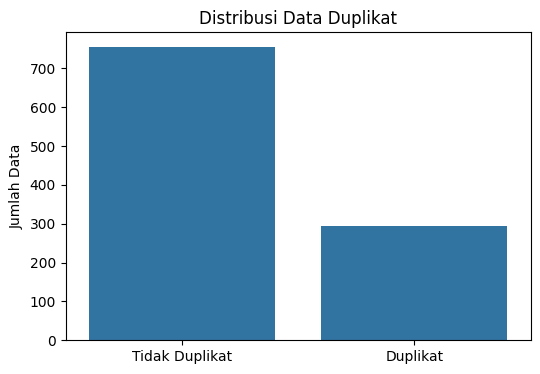

In [19]:
duplicate_count = df[['MO','BARANG BUKTI','PERKARA']].duplicated().sum()

non_duplicate_count = len(df) - duplicate_count

plt.figure(figsize=(6,4))

sns.barplot(
    x=['Tidak Duplikat', 'Duplikat'],
    y=[non_duplicate_count, duplicate_count]
)

plt.title('Distribusi Data Duplikat')
plt.ylabel('Jumlah Data')

plt.show()

Visualisasi Persentase

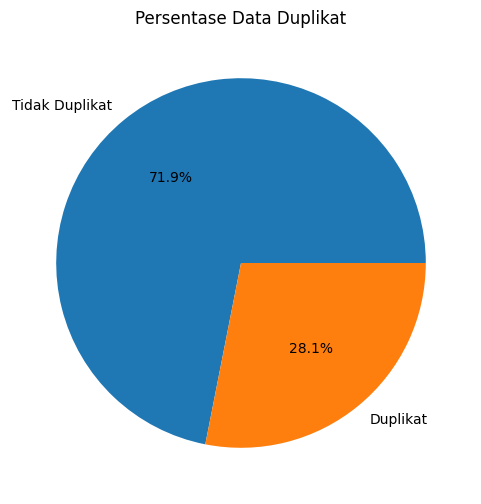

In [20]:
duplicate_count = df[['MO','BARANG BUKTI','PERKARA']].duplicated().sum()

non_duplicate_count = len(df) - duplicate_count

plt.figure(figsize=(6,6))

plt.pie(
    [non_duplicate_count, duplicate_count],
    labels=['Tidak Duplikat', 'Duplikat'],
    autopct='%1.1f%%'
)

plt.title('Persentase Data Duplikat')
plt.show()

# 9. Analisis PROSES

In [21]:
df['PROSES'].value_counts()

PROSES
Sidik          673
Dalam Lidik    234
SIDIK          126
Lidik           11
LIDIK            5
SP3              1
Name: count, dtype: int64

Visualisasi

<Axes: xlabel='count', ylabel='PROSES'>

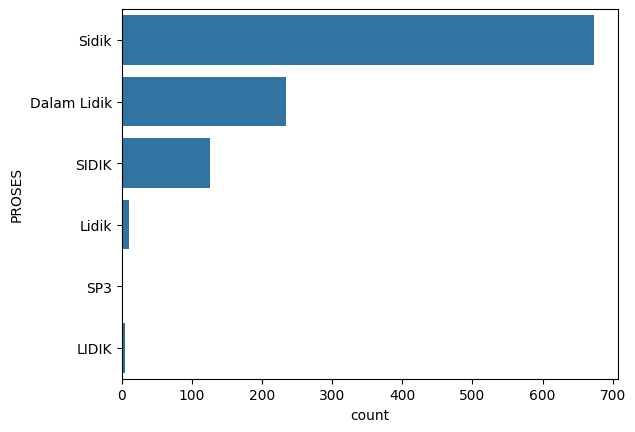

In [22]:
sns.countplot(
    y='PROSES',
    data=df
)

# 10. Analisis Korelasi Fitur terhadap Kelas

Variabel MO berisi kronologi atau modus tindak pidana, sedangkan BARANG BUKTI berisi objek yang ditemukan atau disita pada kasus tersebut. Kedua variabel diperkirakan memiliki hubungan kuat dengan jenis perkara (PERKARA) sehingga digunakan sebagai fitur utama pada proses klasifikasi.